In [1]:
import xarray as xr
import fsspec
#import intake
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
from scipy.stats import ttest_ind, mstats

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

import dask
import pickle

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

# Set up figure

fs = fsspec.filesystem("")

In [2]:
# Location coordinates
locations = {
    'cpt': (-33.8, 18.6),
    'jhb': (-26.1, 28.0),
    'abj': (5.45, -3.9),
    'lua': (-8.994111, 13.439933)
}

names = {'cpt': 'Cape Town', 'jhb': 'Johannesburg', 'abj': 'Abidjan', 'lua': 'Luanda'}

In [3]:
path = '../create_analysis_dataset/data/'
path = 'data/'
var = 'UTCI'  # Can be changed to 'UTCI' or other heat indices
baseline_time = slice('1970', '1999')
recent_time = slice('1993', '2022')

In [4]:
da = xr.open_zarr(f'{path}/heat_analysis_set.zarr')[var] - 273.15
da = da.sel(latitude = slice(20,-60))

baseline = da.sel(time = baseline_time).chunk({"time": -1})
recent = da.sel(time = recent_time).chunk({"time": -1})

In [6]:
# Import GPD from scipy
from scipy.stats import genpareto as gpd, kstest


In [7]:
def fit_gpd(x, threshold_percentile=99):
    """
    Fit GPD to exceedances above threshold (99th percentile)
    """
    x = x[~np.isnan(x)]
    if len(x) < 10:
        return np.array([np.nan, np.nan, np.nan, np.nan])
    
    try:
        # Calculate threshold (99th percentile)
        threshold = np.percentile(x, threshold_percentile)
        
        # Extract exceedances above threshold
        exceedances = x[x > threshold] - threshold
        
        if len(exceedances) < 5:  # Need minimum exceedances to fit
            return np.array([np.nan, np.nan, np.nan, np.nan])
        
        # Fit GPD to exceedances with floc=0
        shape, loc, scale = gpd.fit(exceedances, floc=0)
        
        # Perform Kolmogorov-Smirnov test for goodness of fit
        D, _ = kstest(exceedances, gpd.cdf, args=(shape, loc, scale))
        
        return np.array([shape, scale, threshold, D])
    except Exception:
        return np.array([np.nan, np.nan, np.nan, np.nan])


In [8]:
def return_gpd(da):
    """
    Apply GPD fitting to data array
    """
    params = xr.apply_ufunc(
        fit_gpd,
        da,
        input_core_dims=[["time"]],
        output_core_dims=[["gpd_param"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        dask_gufunc_kwargs={"output_sizes": {"gpd_param": 4}},
    )
    params.name = "gpd_params"
    params.coords["gpd_param"] = ["gpd_shape", "gpd_scale", "gpd_threshold", "ks_stat"]
    
    # Split into individual variables
    split = {
        name: params.isel(gpd_param=i).drop_vars("gpd_param").rename(name)
        for i, name in enumerate(["gpd_shape", "gpd_scale", "gpd_threshold", "ks_stat"])
    }
    
    return xr.Dataset(split).compute()


# Fit GPD to baseline and recent periods
baseline_gpd = return_gpd(baseline)
recent_gpd = return_gpd(recent)


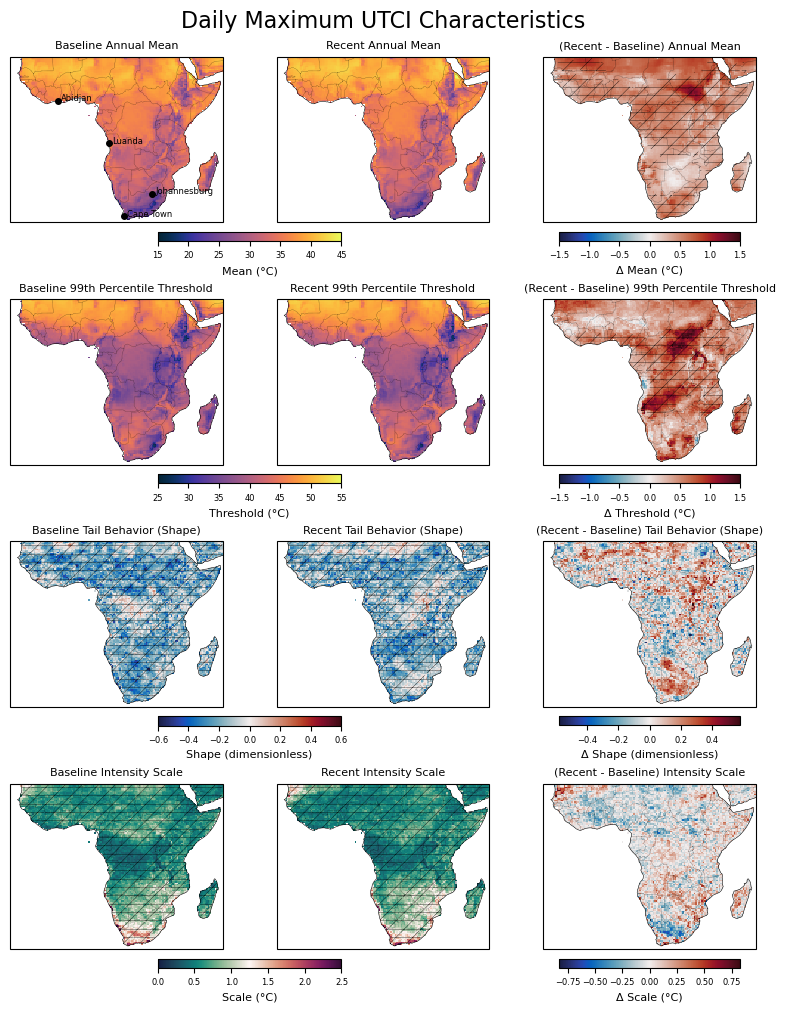

In [12]:
# Calculate differences between recent and baseline GPD
diff_gpd = recent_gpd - baseline_gpd

# Calculate mean UTCI for baseline and recent periods
baseline_mean = baseline.mean(dim='time').compute()
recent_mean = recent.mean(dim='time')
diff_mean = recent_mean - baseline_mean

# Calculate significance following the same approach as 01_exceedence_trends
# Create annual mean time series (with proper chunking)
annual_mean = da.chunk({'time': -1}).resample(time='YE').mean(dim='time').load()
baseline_annual_mean = annual_mean.sel(time=baseline_time)
recent_annual_mean = annual_mean.sel(time=recent_time)

# Calculate significance for mean UTCI changes
mean_significance_temp = diff_mean.to_dataset(name='_')
mean_significance_temp['significance'] = (('latitude','longitude'),
                                         stats.ttest_ind(recent_annual_mean.values, 
                                                        baseline_annual_mean.values)[1])
mean_significance = (mean_significance_temp.significance < 0.05).astype(int)

# Calculate significance for GPD threshold changes (same approach as 01_exceedence_trends)
annual_p99 = da.chunk({'time': -1}).resample(time='YE').quantile(0.99, dim='time').load()
baseline_annual_p99 = annual_p99.sel(time=baseline_time)
recent_annual_p99 = annual_p99.sel(time=recent_time)

threshold_significance_temp = diff_gpd['gpd_threshold'].to_dataset(name='_')
threshold_significance_temp['significance'] = (('latitude','longitude'),
                                              stats.ttest_ind(recent_annual_p99.values,
                                                             baseline_annual_p99.values)[1])
threshold_significance = (threshold_significance_temp.significance < 0.05).astype(int)

# Set up grid and parameters - now including mean UTCI
params = ['mean_utci', 'gpd_threshold', 'gpd_shape', 'gpd_scale']
param_names = ['Annual Mean', '99th Percentile Threshold', 'Tail Behavior (Shape)', 'Intensity Scale']

# Custom plotting configs per parameter
plot_config = {
    'gpd_shape': {'vmin': -0.6, 'vmax': 0.6, 'cmap': cmocean.cm.balance, 'units': '(dimensionless)'},
    'gpd_scale': {'vmin': 0, 'vmax': 2.5, 'cmap': cmocean.cm.curl, 'units': '(°C)'},
    'gpd_threshold': {'vmin': 25, 'vmax': 55, 'cmap': cmocean.cm.thermal, 'units': '(°C)'},
    'mean_utci': {'vmin': 15, 'vmax': 45, 'cmap': cmocean.cm.thermal, 'units': '(°C)'},
}

ks_thresh = 0.1
baseline_goodfit = (baseline_gpd['ks_stat'] <= ks_thresh)
recent_goodfit = (recent_gpd['ks_stat'] <= ks_thresh)

fig, axes = plt.subplots(
    nrows=4, ncols=3, figsize=(8, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

axes = axes.flatten()

# Store image objects for shared colorbars
images_baseline_recent = {}  # For columns 0,1 (baseline, recent)
images_change = {}  # For column 2 (change)

# Plotting loop
for i, param in enumerate(params):
    for j in range(3):  # 3 columns: baseline, recent, change
        idx = i * 3 + j
        ax = axes[idx]
        title_prefix = ["Baseline", "Recent", "(Recent - Baseline)"][j]
        config = plot_config[param]

        # Select appropriate dataset
        if param == 'mean_utci':
            if j == 0:  # Baseline
                dataset = baseline_mean
            elif j == 1:  # Recent
                dataset = recent_mean
            else:  # Change
                dataset = diff_mean
        else:  # GPD parameters
            if j == 0:  # Baseline
                dataset = baseline_gpd[param]
            elif j == 1:  # Recent
                dataset = recent_gpd[param]
            else:  # Change
                dataset = diff_gpd[param]

        # Use balance colormap for difference panels, otherwise use parameter-specific colormap
        plot_cmap = cmocean.cm.balance if j == 2 else config['cmap']
        
        # Don't set vmin/vmax for difference panels, but use them for baseline/recent
        plot_kwargs = {
            'ax': ax,
            'transform': ccrs.PlateCarree(),
            'cmap': plot_cmap,
            'add_colorbar': False
        }
        
        if j != 2:  # Not a difference panel
            plot_kwargs.update({
                'vmin': config['vmin'],
                'vmax': config['vmax']
            })

        if param in (['mean_utci', 'gpd_threshold']):
            if j == 2:
                plot_kwargs.update({
                    'vmin': -1.5,
                    'vmax': 1.5
                })
        
        im = dataset.plot(**plot_kwargs)

        # Store image objects for colorbar creation
        if j <= 1:  # Baseline or Recent
            if param not in images_baseline_recent:
                images_baseline_recent[param] = im
        else:  # Change
            images_change[param] = im

        # Apply significance masks
        if param == 'mean_utci':
            if j == 2: 
                plt.rcParams['hatch.linewidth'] = 0.25 
                mean_significance.plot.contourf(
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    levels=[-0.5, 0.5, 1.5],
                    hatches=[None, "--//"],
                    colors="none",
                    add_colorbar=False,
                    alpha=0
                )
        elif param == 'gpd_threshold':
            if j == 2:
                plt.rcParams['hatch.linewidth'] = 0.25 
                threshold_significance.plot.contourf(
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    levels=[-0.5, 0.5, 1.5],
                    hatches=[None, "--//"],
                    colors="none",
                    add_colorbar=False,
                    alpha=0
                )
        else:
            # For GPD shape and scale parameters, use KS goodness-of-fit test
            if j == 0:  # Baseline
                plt.rcParams['hatch.linewidth'] = 0.25 
                baseline_goodfit.plot.contourf(
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    levels=[-0.5, 0.5, 1.5],
                    hatches=[None, "--//"],
                    colors="none",
                    add_colorbar=False,
                    alpha=0
                )
            elif j == 1:  # Recent
                plt.rcParams['hatch.linewidth'] = 0.25 
                recent_goodfit.plot.contourf(
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    levels=[-0.5, 0.5, 1.5],
                    hatches=[None, "--//"],
                    colors="none",
                    add_colorbar=False,
                    alpha=0
                )

        # Add coastlines/borders/formatting
        ax.set_title(f'{title_prefix} {param_names[i]}', fontsize=8)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
        
        # Add city scatter points only to the first plot (baseline mean UTCI)
        if i == 0 and j == 0:
            for key, (lat, lon) in locations.items():
                ax.plot(lon, lat, marker='o', color='black', markersize=4, transform=ccrs.PlateCarree())
                ax.text(lon + 1, lat, names[key], fontsize=6, color='black', transform=ccrs.PlateCarree())

# Add shared colorbars for baseline/recent (columns 0,1) and separate for change (column 2)
for i, param in enumerate(params):
    config = plot_config[param]
    
    # Shared colorbar for baseline and recent (columns 0,1)
    axes_baseline_recent = [axes[i*3], axes[i*3+1]]  # First two columns of this row
    cbar_br = fig.colorbar(images_baseline_recent[param], ax=axes_baseline_recent, 
                          orientation='horizontal', shrink=0.35, pad=0.05)
    # Simplified baseline/recent labels for colorbar
    baseline_labels = ['Mean', 'Threshold', 'Shape', 'Scale']
    cbar_br.set_label(f'{baseline_labels[i]} {config["units"]}', fontsize=8)
    cbar_br.ax.tick_params(labelsize=6)
    
    # Separate colorbar for change (column 2)
    ax_change = axes[i*3+2]  # Third column of this row
    cbar_ch = fig.colorbar(images_change[param], ax=ax_change, 
                          orientation='horizontal', shrink=0.7, pad=0.05)
    # Simplified change labels for colorbar
    change_labels = ['Δ Mean', 'Δ Threshold', 'Δ Shape', 'Δ Scale']
    cbar_ch.set_label(f'{change_labels[i]} {config["units"]}', fontsize=8)
    cbar_ch.ax.tick_params(labelsize=6)

fig.suptitle('Daily Maximum UTCI Characteristics', 
             fontsize=16)

fig.savefig('plots/02_gpd_trends.png', dpi=300)
plt.show()

Figure 2. Changes in extreme heat event characteristics derived from Generalized Pareto Distribution analysis of UTCI exceedances. Spatial patterns of GPD parameters fitted to daily UTCI values exceeding the 99th percentile threshold during baseline (1970-1999, left column) and recent (1993-2022, middle column) periods, with changes shown in the right column. Top row: Threshold parameter representing the 99th percentile UTCI value (°C), indicating the magnitude of heat required to constitute an extreme event. Middle row: Shape parameter (ξ) controlling the tail behavior of extreme events, where positive values indicate heavy-tailed distributions with greater potential for very extreme events, and negative values suggest bounded extremes. Bottom row: Scale parameter controlling the variability and intensity of extreme heat events above the threshold. All parameters are derived from maximum likelihood estimation with location parameters fixed at zero. Diagonal hatching indicates grid cells where the Kolmogorov-Smirnov goodness-of-fit test statistic is below 0.1, suggesting good model fit.

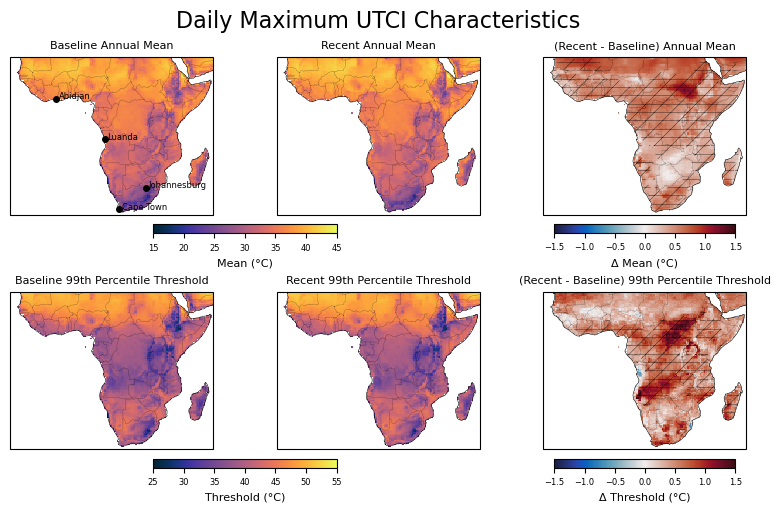

In [11]:
# Calculate differences between recent and baseline GPD
diff_gpd = recent_gpd - baseline_gpd

# Calculate mean UTCI for baseline and recent periods
baseline_mean = baseline.mean(dim='time').compute()
recent_mean = recent.mean(dim='time')
diff_mean = recent_mean - baseline_mean

# Calculate significance following the same approach as 01_exceedence_trends
# Create annual mean time series (with proper chunking)
annual_mean = da.chunk({'time': -1}).resample(time='YE').mean(dim='time').load()
baseline_annual_mean = annual_mean.sel(time=baseline_time)
recent_annual_mean = annual_mean.sel(time=recent_time)

# Calculate significance for mean UTCI changes
mean_significance_temp = diff_mean.to_dataset(name='_')
mean_significance_temp['significance'] = (('latitude','longitude'),
                                         stats.ttest_ind(recent_annual_mean.values, 
                                                        baseline_annual_mean.values)[1])
mean_significance = (mean_significance_temp.significance < 0.05).astype(int)

# Calculate significance for GPD threshold changes (same approach as 01_exceedence_trends)
annual_p99 = da.chunk({'time': -1}).resample(time='YE').quantile(0.99, dim='time').load()
baseline_annual_p99 = annual_p99.sel(time=baseline_time)
recent_annual_p99 = annual_p99.sel(time=recent_time)

threshold_significance_temp = diff_gpd['gpd_threshold'].to_dataset(name='_')
threshold_significance_temp['significance'] = (('latitude','longitude'),
                                              stats.ttest_ind(recent_annual_p99.values,
                                                             baseline_annual_p99.values)[1])
threshold_significance = (threshold_significance_temp.significance < 0.05).astype(int)

# Set up grid and parameters - now including mean UTCI
params = ['mean_utci', 'gpd_threshold']
param_names = ['Annual Mean', '99th Percentile Threshold']

# Custom plotting configs per parameter
plot_config = {
    'gpd_threshold': {'vmin': 25, 'vmax': 55, 'cmap': cmocean.cm.thermal, 'units': '(°C)'},
    'mean_utci': {'vmin': 15, 'vmax': 45, 'cmap': cmocean.cm.thermal, 'units': '(°C)'},
}

fig, axes = plt.subplots(
    nrows=2, ncols=3, figsize=(8, 5),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

axes = axes.flatten()

# Store image objects for shared colorbars
images_baseline_recent = {}  # For columns 0,1 (baseline, recent)
images_change = {}  # For column 2 (change)

# Plotting loop
for i, param in enumerate(params):
    for j in range(3):  # 3 columns: baseline, recent, change
        idx = i * 3 + j
        ax = axes[idx]
        title_prefix = ["Baseline", "Recent", "(Recent - Baseline)"][j]
        config = plot_config[param]

        # Select appropriate dataset
        if param == 'mean_utci':
            if j == 0:  # Baseline
                dataset = baseline_mean
            elif j == 1:  # Recent
                dataset = recent_mean
            else:  # Change
                dataset = diff_mean
        else:  # GPD threshold
            if j == 0:  # Baseline
                dataset = baseline_gpd[param]
            elif j == 1:  # Recent
                dataset = recent_gpd[param]
            else:  # Change
                dataset = diff_gpd[param]

        # Use balance colormap for difference panels, otherwise use parameter-specific colormap
        plot_cmap = cmocean.cm.balance if j == 2 else config['cmap']
        
        # Don't set vmin/vmax for difference panels, but use them for baseline/recent
        plot_kwargs = {
            'ax': ax,
            'transform': ccrs.PlateCarree(),
            'cmap': plot_cmap,
            'add_colorbar': False
        }
        
        if j != 2:  # Not a difference panel
            plot_kwargs.update({
                'vmin': config['vmin'],
                'vmax': config['vmax']
            })

        if param in (['mean_utci', 'gpd_threshold']):
            if j == 2:
                plot_kwargs.update({
                    'vmin': -1.5,
                    'vmax': 1.5
                })
        
        im = dataset.plot(**plot_kwargs)

        # Store image objects for colorbar creation
        if j <= 1:  # Baseline or Recent
            if param not in images_baseline_recent:
                images_baseline_recent[param] = im
        else:  # Change
            images_change[param] = im

        # Apply significance masks
        if param == 'mean_utci':
            if j == 2: 
                plt.rcParams['hatch.linewidth'] = 0.25 
                mean_significance.plot.contourf(
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    levels=[-0.5, 0.5, 1.5],
                    hatches=[None, "--//"],
                    colors="none",
                    add_colorbar=False,
                    alpha=0
                )
        elif param == 'gpd_threshold':
            if j == 2:
                plt.rcParams['hatch.linewidth'] = 0.25 
                threshold_significance.plot.contourf(
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    levels=[-0.5, 0.5, 1.5],
                    hatches=[None, "--//"],
                    colors="none",
                    add_colorbar=False,
                    alpha=0
                )

        # Add coastlines/borders/formatting
        ax.set_title(f'{title_prefix} {param_names[i]}', fontsize=8)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
        
        # Add city scatter points only to the first plot (baseline mean UTCI)
        if i == 0 and j == 0:
            for key, (lat, lon) in locations.items():
                ax.plot(lon, lat, marker='o', color='black', markersize=4, transform=ccrs.PlateCarree())
                ax.text(lon + 1, lat, names[key], fontsize=6, color='black', transform=ccrs.PlateCarree())

# Add shared colorbars for baseline/recent (columns 0,1) and separate for change (column 2)
for i, param in enumerate(params):
    config = plot_config[param]
    
    # Shared colorbar for baseline and recent (columns 0,1)
    axes_baseline_recent = [axes[i*3], axes[i*3+1]]  # First two columns of this row
    cbar_br = fig.colorbar(images_baseline_recent[param], ax=axes_baseline_recent, 
                          orientation='horizontal', shrink=0.35, pad=0.05)
    # Simplified baseline/recent labels for colorbar
    baseline_labels = ['Mean', 'Threshold']
    cbar_br.set_label(f'{baseline_labels[i]} {config["units"]}', fontsize=8)
    cbar_br.ax.tick_params(labelsize=6)
    
    # Separate colorbar for change (column 2)
    ax_change = axes[i*3+2]  # Third column of this row
    cbar_ch = fig.colorbar(images_change[param], ax=ax_change, 
                          orientation='horizontal', shrink=0.7, pad=0.05)
    # Simplified change labels for colorbar
    change_labels = ['Δ Mean', 'Δ Threshold']
    cbar_ch.set_label(f'{change_labels[i]} {config["units"]}', fontsize=8)
    cbar_ch.ax.tick_params(labelsize=6)

fig.suptitle('Daily Maximum UTCI Characteristics', 
             fontsize=16)

fig.savefig('plots/02_gpd_trends_no_gpd.png', dpi=300)
plt.show()


Figure 2. Changes in UTCI characteristics between baseline and recent periods. Spatial patterns of annual mean UTCI and extreme heat thresholds during baseline (1970-1999, left column) and recent (1993-2022, middle column) periods, with changes shown in the right column. Top row: Annual mean UTCI (°C), representing the average thermal stress conditions. Bottom row: 99th percentile threshold (°C), indicating the magnitude of heat required to constitute an extreme event. Diagonal hatching in the change panels indicates grid cells where differences are statistically significant (p < 0.05) based on t-tests comparing annual values between periods. Black dots and labels show major cities for geographic reference.

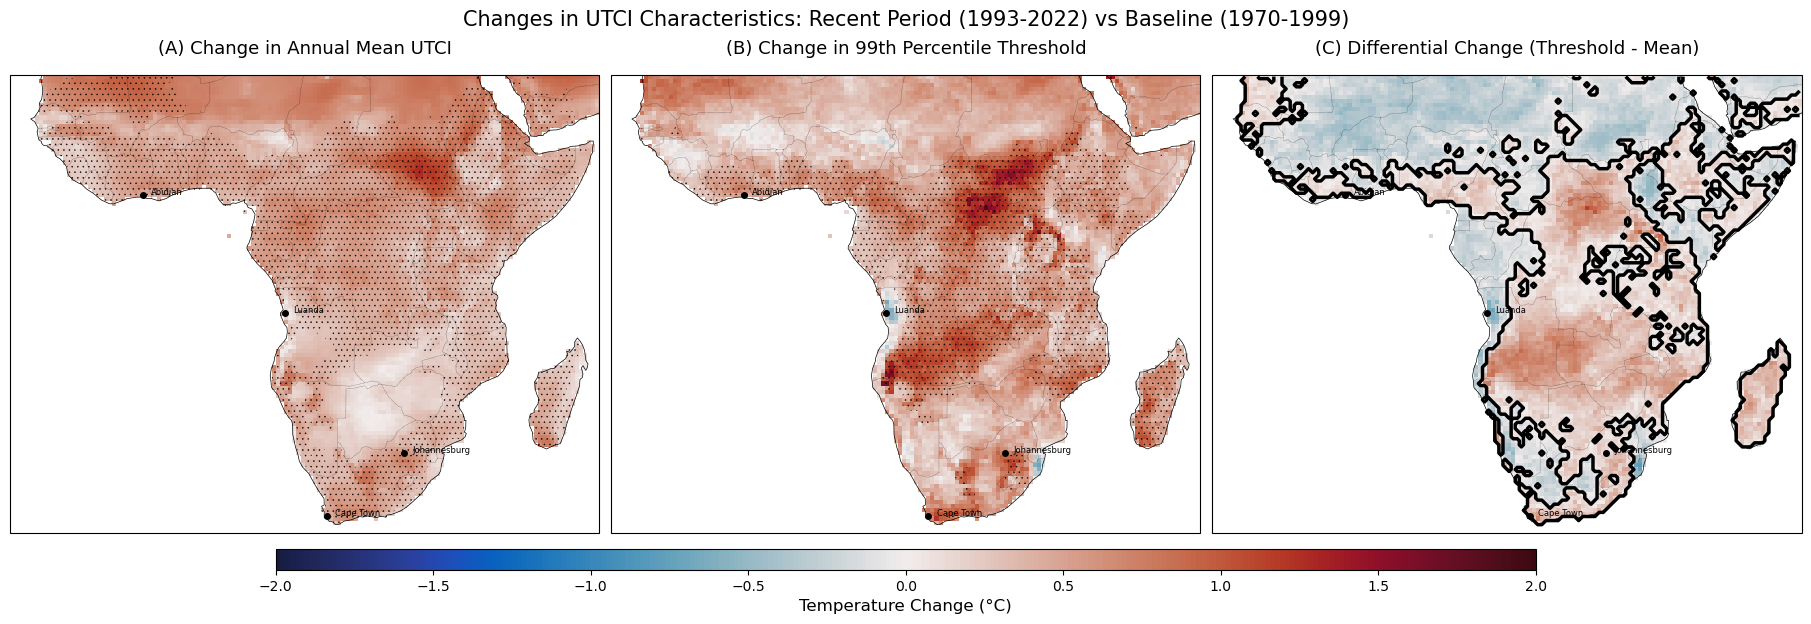

In [21]:
# Create improved 3-panel plot with better layout and clarity
fig, axes = plt.subplots(1, 3, figsize=(18, 7), 
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        constrained_layout=True)

# Calculate the anomaly (threshold - mean change)
threshold_mean_anomaly = diff_gpd['gpd_threshold'] - diff_mean

# Panel 1: Mean UTCI Change
ax1 = axes[0]
im1 = diff_mean.plot(ax=ax1, transform=ccrs.PlateCarree(),
                     cmap=cmocean.cm.balance,
                     add_colorbar=False,
                     vmin=-2, vmax=2)

# Add significance hatching for mean changes
if 'mean_significance' in locals():
    plt.rcParams['hatch.linewidth'] = 0.3
    mean_significance.plot.contourf(
        ax=ax1,
        transform=ccrs.PlateCarree(),
        levels=[-0.5, 0.5, 1.5],
        hatches=[None, "..."],
        colors="none",
        add_colorbar=False,
        alpha=0
    )

ax1.set_title('(A) Change in Annual Mean UTCI', fontsize=13, pad=15)
ax1.coastlines(linewidth=0.5)
ax1.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")

# Panel 2: Threshold Change  
ax2 = axes[1]
im2 = diff_gpd['gpd_threshold'].plot(ax=ax2, transform=ccrs.PlateCarree(),
                                     cmap=cmocean.cm.balance,
                                     add_colorbar=False,
                                     vmin=-2, vmax=2)

# Add significance hatching for threshold changes
if 'threshold_significance' in locals():
    plt.rcParams['hatch.linewidth'] = 0.3
    threshold_significance.plot.contourf(
        ax=ax2,
        transform=ccrs.PlateCarree(),
        levels=[-0.5, 0.5, 1.5],
        hatches=[None, "..."],
        colors="none",
        add_colorbar=False,
        alpha=0
    )

ax2.set_title('(B) Change in 99th Percentile Threshold', fontsize=13, pad=15)
ax2.coastlines(linewidth=0.5)
ax2.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")

# Panel 3: Anomaly (Threshold - Mean) with contours
ax3 = axes[2]
im3 = threshold_mean_anomaly.plot(ax=ax3, transform=ccrs.PlateCarree(),
                                  cmap=cmocean.cm.balance,
                                  add_colorbar=False,
                                  vmin=-2, vmax=2)

# Add contours where threshold increase > mean increase
threshold_exceeds_mean = threshold_mean_anomaly > 0
threshold_exceeds_mean.plot.contour(ax=ax3, transform=ccrs.PlateCarree(),
                                   levels=[0.5], colors='black', linewidths=2.5)

ax3.set_title('(C) Differential Change (Threshold - Mean)', fontsize=13, pad=15)
ax3.coastlines(linewidth=0.5)
ax3.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")

# Add city markers to all panels for reference
for ax in axes:
    for key, (lat, lon) in locations.items():
        ax.plot(lon, lat, marker='o', color='black', markersize=4, transform=ccrs.PlateCarree())
        ax.text(lon + 1, lat, names[key], fontsize=6, color='black', transform=ccrs.PlateCarree())

# Adjust subplot spacing
#plt.subplots_adjust(bottom=0.25, top=0.85, left=0.05, right=0.95, wspace=0.1)

# Add shared colorbar with better positioning - placed below the plots
cbar_ax = fig.add_axes([0.15, 0.12, 0.7, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im1, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Temperature Change (°C)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Add overall title with better spacing
fig.suptitle('Changes in UTCI Characteristics: Recent Period (1993-2022) vs Baseline (1970-1999)', 
             fontsize=15, y=0.92)

fig.savefig('plots/02_extreme_vs_mean', dpi=300)

plt.show()


Figure 3. Comparison of mean UTCI and extreme heat changes between baseline (1970-1999) and recent (1993-2022) periods. (A) Left panel: Change in annual mean UTCI showing widespread warming across most regions. (B) Center panel: Change in 99th percentile threshold indicating how the baseline for extreme heat events has shifted. (C) Right panel: Differential change (threshold minus mean change) with black contours delineating areas where extreme heat increases faster than mean temperature. Stippling in panels A and B indicates regions where changes are statistically significant (p < 0.05 based on t-tests of annual values). White circles mark major cities for geographic reference. This comparison reveals spatial patterns of disproportionate extreme heat intensification, where some regions experience greater increases in extreme heat thresholds relative to their mean temperature changes, indicating enhanced extreme heat risk beyond what would be expected from mean warming alone.


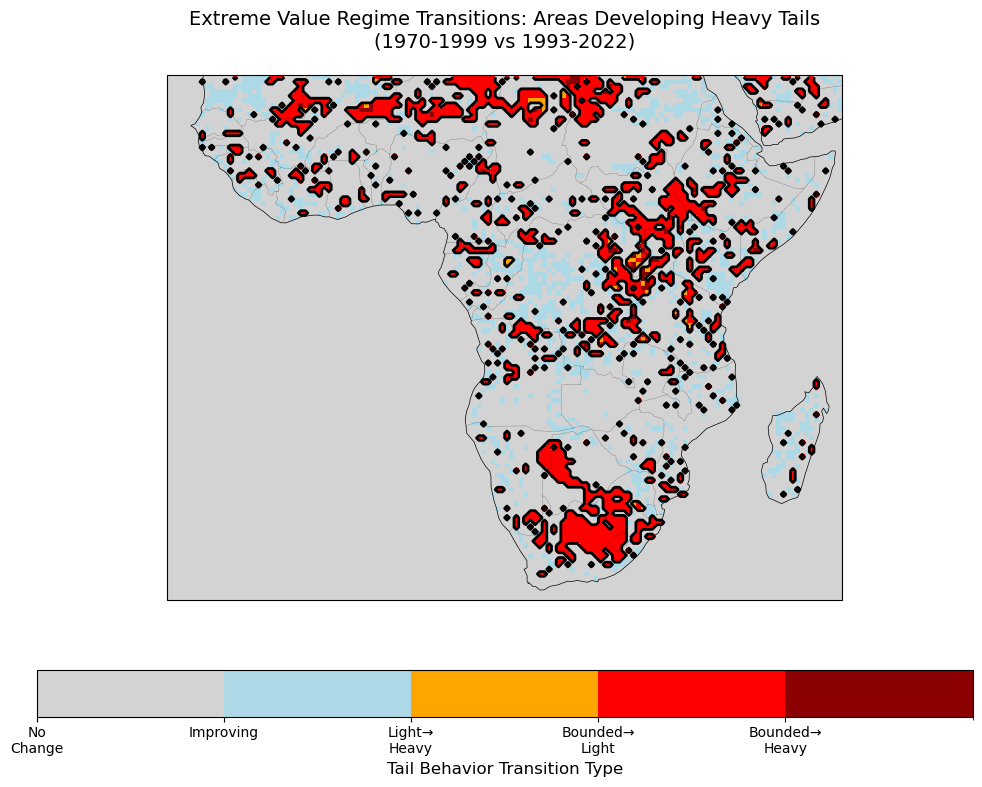

=== EXTREME VALUE REGIME TRANSITIONS ===
No change in regime: 13496 grid cells
Improving (heavy → light/bounded): 1071 grid cells
Light → Heavy tail: 37 grid cells
Bounded → Light tail: 1471 grid cells
Bounded → Heavy tail (most concerning): 53 grid cells
Total grid cells: 16128

Areas developing heavy tails (orange+red): 1561 grid cells (9.7%)
Most concerning transitions (bounded→heavy): 53 grid cells (0.3%)

=== SHAPE PARAMETER CONTEXT ===
Baseline period - Mean shape: -0.182
Recent period - Mean shape: -0.162
Overall shape change: 0.020


In [11]:
# Analyze shape parameter regime changes
shape_baseline = baseline_gpd['gpd_shape']
shape_recent = recent_gpd['gpd_shape']

# Define different tail regimes
# Heavy tail threshold - above this we consider "heavy-tailed"
heavy_tail_threshold = 0.1

# Classify baseline and recent periods
baseline_regime = xr.where(shape_baseline < -0.1, 'bounded', 
                  xr.where(shape_baseline < heavy_tail_threshold, 'light', 'heavy'))
recent_regime = xr.where(shape_recent < -0.1, 'bounded',
                xr.where(shape_recent < heavy_tail_threshold, 'light', 'heavy'))

# Identify transition types
transitions = xr.where(
    (baseline_regime == 'bounded') & (recent_regime == 'heavy'), 4,  # Bounded → Heavy (most dramatic)
    xr.where(
        (baseline_regime == 'bounded') & (recent_regime == 'light'), 3,  # Bounded → Light  
        xr.where(
            (baseline_regime == 'light') & (recent_regime == 'heavy'), 2,  # Light → Heavy
            xr.where(
                (baseline_regime == recent_regime), 0,  # No change
                1  # Other transitions (heavy → light/bounded)
            )
        )
    )
)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8), 
                      subplot_kw={'projection': ccrs.PlateCarree()})

# Define colors for different transition types
colors = ['lightgray', 'lightblue', 'orange', 'red', 'darkred']

im = transitions.plot(ax=ax, transform=ccrs.PlateCarree(),
                     add_colorbar=False,
                     levels=[0, 1, 2, 3, 4, 5],
                     colors=colors)

# Add contours for the most concerning transitions
concerning_transitions = (transitions >= 2)  # Light→Heavy or Bounded→Heavy
concerning_transitions.plot.contour(ax=ax, transform=ccrs.PlateCarree(),
                                   levels=[0.5], colors='black', linewidths=2)

# Add coastlines and borders
ax.coastlines(linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")

# Add title
ax.set_title('Extreme Value Regime Transitions: Areas Developing Heavy Tails\n(1970-1999 vs 1993-2022)', 
             fontsize=14, pad=20)

# Custom colorbar
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', shrink=0.8, pad=0.1)
cbar.set_label('Tail Behavior Transition Type', fontsize=12)
cbar.set_ticks([0, 1, 2, 3, 4])
cbar.set_ticklabels(['No\nChange', 'Improving', 'Light→\nHeavy', 'Bounded→\nLight', 'Bounded→\nHeavy'])

plt.tight_layout()
plt.show()

# Statistics on regime transitions
print("=== EXTREME VALUE REGIME TRANSITIONS ===")
print(f"No change in regime: {(transitions == 0).sum().values} grid cells")
print(f"Improving (heavy → light/bounded): {(transitions == 1).sum().values} grid cells")
print(f"Light → Heavy tail: {(transitions == 2).sum().values} grid cells")
print(f"Bounded → Light tail: {(transitions == 3).sum().values} grid cells") 
print(f"Bounded → Heavy tail (most concerning): {(transitions == 4).sum().values} grid cells")
print(f"Total grid cells: {transitions.count().values}")

# Key statistics
concerning = (transitions >= 2).sum().values
total = transitions.count().values
print(f"\nAreas developing heavy tails (orange+red): {concerning} grid cells ({concerning/total*100:.1f}%)")

most_concerning = (transitions == 4).sum().values
print(f"Most concerning transitions (bounded→heavy): {most_concerning} grid cells ({most_concerning/total*100:.1f}%)")

# Show baseline vs recent shape statistics for context
print(f"\n=== SHAPE PARAMETER CONTEXT ===")
print(f"Baseline period - Mean shape: {shape_baseline.mean().values:.3f}")
print(f"Recent period - Mean shape: {shape_recent.mean().values:.3f}")
print(f"Overall shape change: {(shape_recent - shape_baseline).mean().values:.3f}")

Figure X. Transitions in extreme value tail behavior from Generalized Pareto Distribution shape parameter analysis. Spatial patterns of changes in extreme value regime classification between baseline (1970-1999) and recent (1993-2022) periods based on GPD shape parameter (ξ) fitted to daily UTCI exceedances above the 99th percentile threshold. Tail regimes are classified as: bounded (ξ < -0.1, finite upper limit to extremes), light (ξ: -0.1 to 0.1, moderate extreme potential), and heavy (ξ > 0.1, no theoretical upper bound to extreme events). Gray areas: No regime change between periods. Light blue: Improving conditions (heavy-tailed → light or bounded regimes). Orange: Light-tailed → heavy-tailed transitions, indicating development of more extreme tail behavior. Red: Bounded → light-tailed transitions. Dark red: Most concerning transitions from bounded → heavy-tailed regimes, representing fundamental shifts from finite to potentially unlimited extreme heat potential. Black contours delineate areas developing heavy-tailed behavior (orange and dark red regions combined). These regime transitions indicate changes in the fundamental statistical nature of extreme heat events, with implications for risk assessment, infrastructure design, and emergency preparedness. Areas developing heavy tails suggest increasing potential for unprecedented extreme heat events that exceed historical bounds.

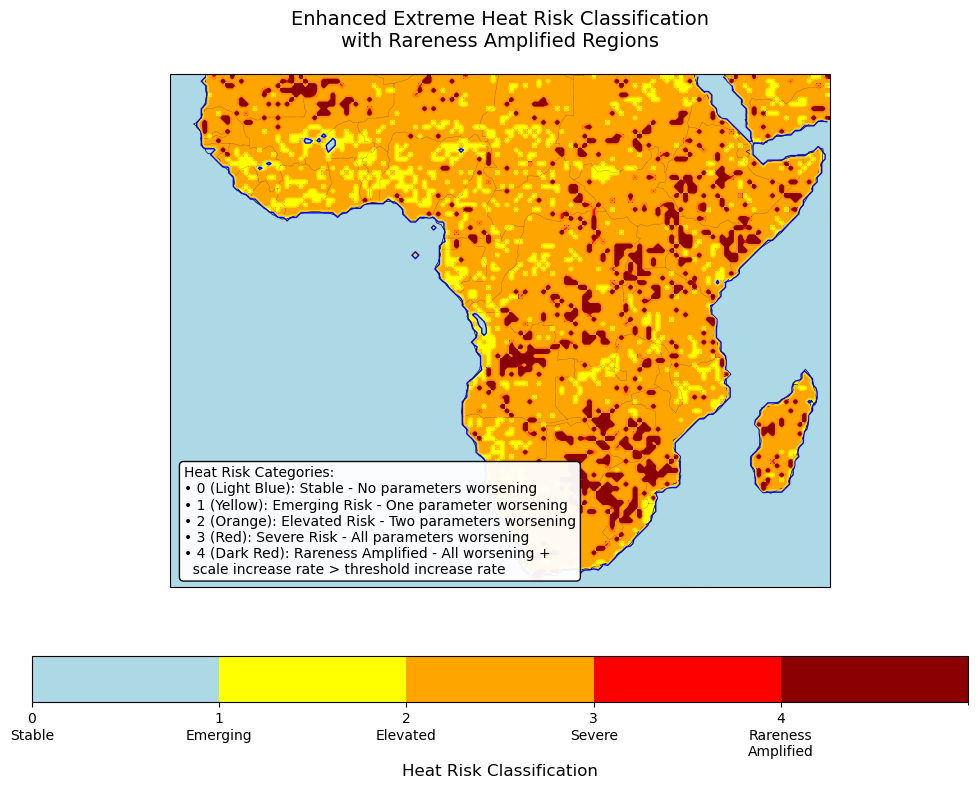

=== ENHANCED EXTREME HEAT RISK ANALYSIS ===
Stable regions (0): 8274 grid cells
Emerging risk (1): 949 grid cells
Elevated risk (2): 5984 grid cells
Severe risk (3): 91 grid cells
RARENESS AMPLIFIED (4): 830 grid cells
Total grid cells: 16128
High risk areas (3-4): 5.7%
Rareness amplified areas: 5.1%

=== RARENESS AMPLIFIED REGIONS DETAIL ===
Mean scale % increase in these regions: 11.7%
Mean threshold % increase in these regions: 1.4%
Amplification ratio (scale/threshold): 8.64


In [13]:
# Calculate percentage changes for scale and threshold
baseline_scale = baseline_gpd['gpd_scale']
baseline_threshold = baseline_gpd['gpd_threshold']
scale_pct_change = (diff_gpd['gpd_scale'] / baseline_scale) * 100
threshold_pct_change = (diff_gpd['gpd_threshold'] / baseline_threshold) * 100

# Define worsening conditions
threshold_increase = diff_gpd['gpd_threshold'] > 0  # Higher baseline for extremes
scale_increase = diff_gpd['gpd_scale'] > 0         # More variable extremes  
shape_increase = diff_gpd['gpd_shape'] > 0         # Heavier tails

# Create enhanced severity indicator (0-4 scale)
severity_indicator = (threshold_increase.astype(int) + 
                     scale_increase.astype(int) + 
                     shape_increase.astype(int))

# Identify "rareness amplified regions" - all 3 worsening + scale % increase > threshold % increase
all_three_worsening = (threshold_increase & scale_increase & shape_increase)
rareness_amplified = all_three_worsening & (scale_pct_change > threshold_pct_change)

# Update severity indicator: set rareness amplified regions to 4
severity_indicator_enhanced = severity_indicator.copy()
severity_indicator_enhanced = severity_indicator_enhanced.where(~rareness_amplified, 4)

# Create the plot with enhanced color scheme
fig, ax = plt.subplots(1, 1, figsize=(12, 8), 
                      subplot_kw={'projection': ccrs.PlateCarree()})

# Use discrete colors - remove cmap parameter
colors = ['lightblue', 'yellow', 'orange', 'red', 'darkred']
im = severity_indicator_enhanced.plot(ax=ax, transform=ccrs.PlateCarree(),
                                     add_colorbar=False,
                                     levels=[0, 1, 2, 3, 4, 5],
                                     colors=colors)

# Add contours for different severity levels
severity_indicator_enhanced.plot.contour(ax=ax, transform=ccrs.PlateCarree(),
                                        levels=[0.5, 1.5, 2.5, 3.5, 4.5], 
                                        colors=['blue', 'gold', 'darkorange', 'darkred', 'black'], 
                                        linewidths=[1, 1, 1.5, 2, 2.5])

# Add coastlines and borders
ax.coastlines(linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")

# Add title
ax.set_title('Enhanced Extreme Heat Risk Classification\nwith Rareness Amplified Regions', 
             fontsize=14, pad=20)

# Custom colorbar
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', shrink=0.8, pad=0.1)
cbar.set_label('Heat Risk Classification', fontsize=12)
cbar.set_ticks([0, 1, 2, 3, 4])
cbar.set_ticklabels(['0\nStable', '1\nEmerging', '2\nElevated', '3\nSevere', '4\nRareness\nAmplified'])

# Enhanced legend
legend_text = """Heat Risk Categories:
• 0 (Light Blue): Stable - No parameters worsening
• 1 (Yellow): Emerging Risk - One parameter worsening  
• 2 (Orange): Elevated Risk - Two parameters worsening
• 3 (Red): Severe Risk - All parameters worsening
• 4 (Dark Red): Rareness Amplified - All worsening + 
  scale increase rate > threshold increase rate"""

ax.text(0.02, 0.02, legend_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.95, edgecolor='black'))

plt.tight_layout()
plt.show()

# Enhanced statistics
print("=== ENHANCED EXTREME HEAT RISK ANALYSIS ===")
print(f"Stable regions (0): {(severity_indicator_enhanced == 0).sum().values} grid cells")
print(f"Emerging risk (1): {(severity_indicator_enhanced == 1).sum().values} grid cells") 
print(f"Elevated risk (2): {(severity_indicator_enhanced == 2).sum().values} grid cells")
print(f"Severe risk (3): {(severity_indicator_enhanced == 3).sum().values} grid cells")
print(f"RARENESS AMPLIFIED (4): {(severity_indicator_enhanced == 4).sum().values} grid cells")
print(f"Total grid cells: {severity_indicator_enhanced.count().values}")
print(f"High risk areas (3-4): {((severity_indicator_enhanced >= 3).sum() / severity_indicator_enhanced.count() * 100).values:.1f}%")
print(f"Rareness amplified areas: {((severity_indicator_enhanced == 4).sum() / severity_indicator_enhanced.count() * 100).values:.1f}%")

# Additional statistics on rareness amplified regions
rareness_areas = severity_indicator_enhanced == 4
if rareness_areas.sum().values > 0:
    print(f"\n=== RARENESS AMPLIFIED REGIONS DETAIL ===")
    mean_scale_pct = scale_pct_change.where(rareness_areas).mean().values
    mean_threshold_pct = threshold_pct_change.where(rareness_areas).mean().values
    print(f"Mean scale % increase in these regions: {mean_scale_pct:.1f}%")
    print(f"Mean threshold % increase in these regions: {mean_threshold_pct:.1f}%")
    print(f"Amplification ratio (scale/threshold): {mean_scale_pct/mean_threshold_pct:.2f}")